# Hier-Online Learned Prior Width vs True Block Prior

This notebook is the Hier-Online version of the prior-width diagnostic. It
compares the model's learned prior SD trajectory with the experiment's true
block prior SD (`10`, `20`, `40`, `80` deg), participant by participant.

Important: Hier-Online learns both prior mean and prior width online. During
replay this notebook passes `session_id`, matching the registry prediction path
so the learner resets at session boundaries.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

HERE = Path.cwd()
HIERARCHICAL_ROOT = HERE.parents[1]
sys.path.insert(0, str(HIERARCHICAL_ROOT))

from observers import api
from observers.comparison.registry import build_registry, load_subject as load_model_subject

MODEL = "hierarchical_online"
MODEL_LABEL = "Hier-Online"
DATA_CSV = HIERARCHICAL_ROOT / "data" / "data01_direction4priors.csv"
RESULTS_DIR = HERE / "results"
FIGURES_DIR = HERE / "figures"
STATE_CSV = RESULTS_DIR / "hier_online_trial_learning_state.csv"
PDF_PATH = HERE / "hier_online_prior_width_vs_true_blocks.pdf"
PREVIEW_PATH = FIGURES_DIR / "hier_online_prior_width_vs_true_blocks_page1.png"

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

FORCE_REPLAY = os.environ.get("HIER_ONLINE_FORCE_REPLAY", "0") == "1"
SUBJECTS = api.subjects_with_data()
registry = build_registry([MODEL])
print("subjects:", SUBJECTS)
print("fitted Hier-Online subjects:", api.fitted_subjects(MODEL))


subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
fitted Hier-Online subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [2]:
def load_design_with_metadata(subject_id: int) -> pd.DataFrame:
    df = pd.read_csv(DATA_CSV)
    df = (
        df.loc[df["subject_id"].eq(subject_id)]
        .sort_values(["subject_id", "session_id", "run_id", "trial_index"], kind="mergesort")
        .reset_index(drop=True)
    )
    keep = df[
        [
            "subject_id",
            "session_id",
            "run_id",
            "trial_index",
            "motion_direction",
            "motion_coherence",
            "prior_std",
        ]
    ].copy()
    keep = keep.dropna(subset=["motion_direction", "motion_coherence"]).reset_index(drop=True)
    keep["motion_direction"] = keep["motion_direction"].round().astype(int).clip(1, 360)
    keep["chronological_trial"] = np.arange(1, len(keep) + 1)
    keep["block_key"] = (
        keep["subject_id"].astype(str)
        + "_s"
        + keep["session_id"].astype(str)
        + "_r"
        + keep["run_id"].astype(str)
    )
    block_pos = keep.groupby("block_key").cumcount()
    block_n = keep.groupby("block_key")["trial_index"].transform("size")
    frac = (block_pos + 0.5) / block_n
    keep["block_trial_position"] = block_pos + 1
    keep["block_n_trials"] = block_n
    keep["block_phase"] = np.select(
        [frac < 1.0 / 3.0, frac < 2.0 / 3.0],
        ["early", "middle"],
        default="late",
    )
    return keep


def replay_hier_online_subject(subject_id: int) -> pd.DataFrame:
    obs, fit_record = api.load_fitted(MODEL, subject_id)
    data = load_model_subject(subject_id)
    design = load_design_with_metadata(subject_id)
    if len(design) != len(data["motion_direction"]):
        raise ValueError(
            f"subject {subject_id}: metadata length {len(design)} does not match "
            f"model data length {len(data['motion_direction'])}"
        )
    out = obs.filter(
        data["motion_direction"],
        data["motion_coherence"],
        feedback=data["motion_direction"],
        session_id=data.get("session_id"),
        record_belief=True,
    )
    design["believed_sd"] = out["believed_sd"]
    design["k_traj"] = out.get("k_traj", np.nan)
    design["mu_traj"] = out.get("mu_traj", np.nan)
    design["model"] = MODEL
    design["model_label"] = fit_record.get("label", MODEL_LABEL)
    design["nll"] = fit_record.get("nll", np.nan)
    design["aic"] = fit_record.get("aic", np.nan)
    design["bic"] = fit_record.get("bic", np.nan)
    convergence = fit_record.get("convergence") or {}
    design["fit_converged"] = bool(convergence.get("converged", False))
    design["start_spread"] = float(fit_record.get("start_spread", np.nan))
    return design


In [3]:
if FORCE_REPLAY or not STATE_CSV.exists():
    rows = []
    for subject_id in SUBJECTS:
        if subject_id not in api.fitted_subjects(MODEL):
            print(f"skipping subject {subject_id}: no saved Hier-Online fit")
            continue
        one = replay_hier_online_subject(subject_id)
        rows.append(one)
        print(f"replayed subject {subject_id}: {len(one)} trials")
    state = pd.concat(rows, ignore_index=True)
    state.to_csv(STATE_CSV, index=False)
    print("wrote", STATE_CSV)
else:
    state = pd.read_csv(STATE_CSV)
    print("loaded cached state:", STATE_CSV)

display(state.head())
print("participants:", sorted(state["subject_id"].unique()))


replayed subject 1: 8562 trials


replayed subject 2: 7877 trials


replayed subject 3: 9412 trials


C:\Users\HP\Desktop\baysiean hyperprior\hierarchical\observers\helpers\dataset.py:80: RuntimeWarning: invalid value encountered in cast
  df["estimate_dir"] = np.round(ang).astype(int).clip(1, 360)


replayed subject 4: 4801 trials


...

replayed subject 11: 6474 trials


replayed subject 12: 6474 trials


wrote C:\Users\HP\Desktop\baysiean hyperprior\hierarchical\experiments\salma\results\hier_online_trial_learning_state.csv


,subject_id,session_id,run_id,trial_index,motion_direction,motion_coherence,prior_std,chronological_trial,block_key,block_trial_position,...,believed_sd,k_traj,mu_traj,model,model_label,nll,aic,bic,fit_converged,start_spread
0,1,1,1,1,225,0.12,10,1,1_s1_r1,1,...,103.920201,0.000116,225.000000,hierarchical_online,Hier-Online,39489.908188,78995.816375,79052.257088,True,671.662658
1,1,1,1,2,225,0.12,10,2,1_s1_r1,2,...,97.344004,0.205352,225.000000,hierarchical_online,Hier-Online,39489.908188,78995.816375,79052.257088,True,671.662658
2,1,1,1,3,235,0.06,10,3,1_s1_r1,3,...,91.190472,0.395156,225.000000,hierarchical_online,Hier-Online,39489.908188,78995.816375,79052.257088,True,671.662658
3,1,1,1,4,225,0.06,10,4,1_s1_r1,4,...,85.488164,0.572768,228.694350,hierarchical_online,Hier-Online,39489.908188,78995.816375,79052.257088,True,671.662658
4,1,1,1,5,215,0.24,10,5,1_s1_r1,5,...,80.066017,0.746329,227.614307,hierarchical_online,Hier-Online,39489.908188,78995.816375,79052.257088,True,671.662658


participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [4]:
PRIOR_STDS = [10, 20, 40, 80]
PRIOR_BAND_COLORS = {
    10: "#e8f4fb",
    20: "#e7f4e4",
    40: "#fff1cc",
    80: "#f8dddd",
}


def add_prior_bands(ax, trials: np.ndarray, prior_std: np.ndarray) -> None:
    breaks = np.r_[0, np.flatnonzero(prior_std[1:] != prior_std[:-1]) + 1, len(prior_std)]
    for start, stop in zip(breaks[:-1], breaks[1:]):
        value = int(prior_std[start])
        ax.axvspan(
            trials[start] - 0.5,
            trials[stop - 1] + 0.5,
            color=PRIOR_BAND_COLORS.get(value, "#f3f3f3"),
            alpha=0.34,
            linewidth=0,
            zorder=0,
        )


def plot_subject(ax, subject_state: pd.DataFrame) -> None:
    subject_state = subject_state.sort_values(
        ["session_id", "run_id", "trial_index"], kind="mergesort"
    ).reset_index(drop=True)
    sid = int(subject_state["subject_id"].iloc[0])
    trial = np.arange(1, len(subject_state) + 1)
    prior = subject_state["prior_std"].to_numpy(dtype=float)
    learned = subject_state["believed_sd"].to_numpy(dtype=float)
    rolling = pd.Series(learned).rolling(50, min_periods=1).mean().to_numpy()

    add_prior_bands(ax, trial, prior)
    ax.plot(
        trial,
        learned,
        color="#9ac56b",
        lw=0.55,
        alpha=0.32,
        label="learned prior SD, trial",
        zorder=2,
    )
    ax.plot(
        trial,
        rolling,
        color="#3a7d44",
        lw=1.8,
        label="learned prior SD, 50-trial mean",
        zorder=3,
    )
    ax.step(
        trial,
        prior,
        where="post",
        color="#111111",
        lw=2.4,
        label="true block prior SD",
        zorder=4,
    )
    ax.set_title(f"Participant {sid}", loc="left", fontsize=10, pad=3)
    ax.set_ylim(0, 90)
    ax.set_yticks([0, 10, 20, 40, 80])
    ax.set_ylabel("prior SD (deg)")
    ax.grid(alpha=0.18)


def make_page_figure(page_subjects):
    fig, axes = plt.subplots(
        len(page_subjects),
        1,
        figsize=(11, 8.5),
        sharex=False,
        squeeze=False,
    )
    fig.suptitle(
        "Hier-Online learned prior width compared with true block prior",
        fontsize=14,
        y=0.985,
    )
    for i, subject_id in enumerate(page_subjects):
        ax = axes[i, 0]
        plot_subject(ax, state[state["subject_id"].eq(subject_id)])
        if i == len(page_subjects) - 1:
            ax.set_xlabel("chronological trial")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        fontsize=8,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01),
    )
    fig.tight_layout(rect=[0, 0.055, 1, 0.965])
    return fig


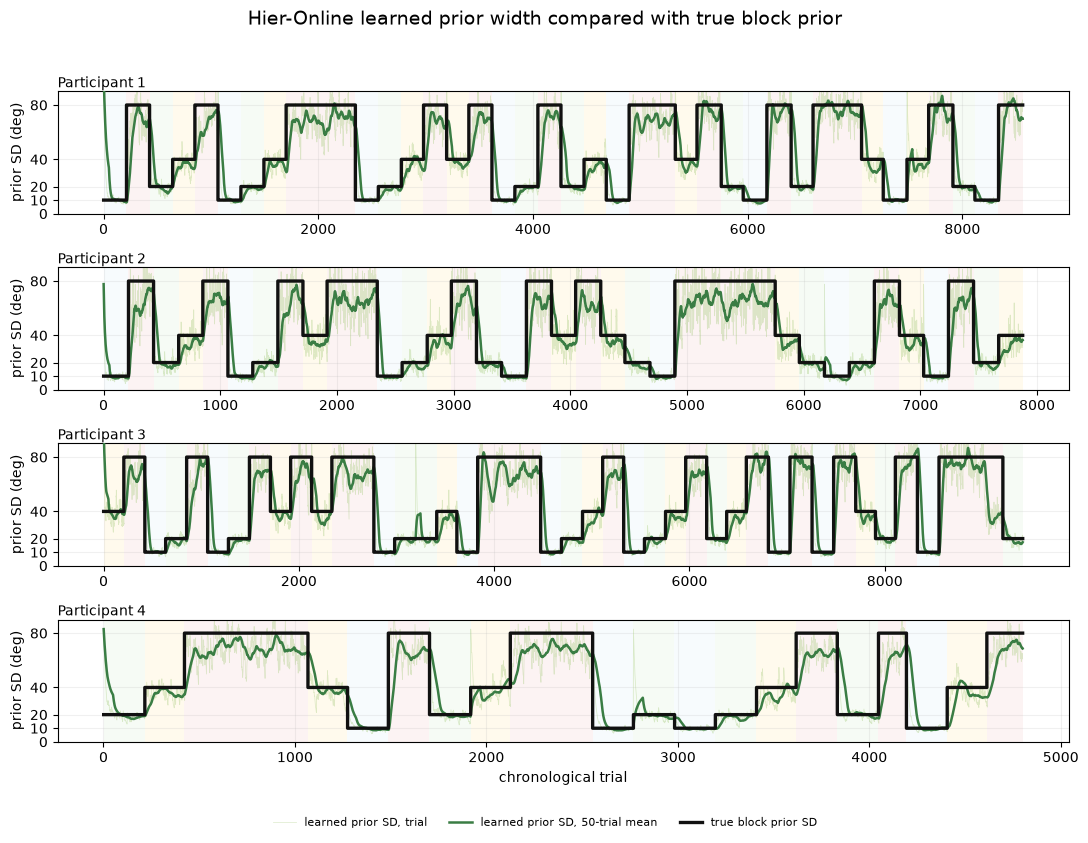

wrote PDF: C:\Users\HP\Desktop\baysiean hyperprior\hierarchical\experiments\salma\hier_online_prior_width_vs_true_blocks.pdf
wrote preview: C:\Users\HP\Desktop\baysiean hyperprior\hierarchical\experiments\salma\figures\hier_online_prior_width_vs_true_blocks_page1.png


In [5]:
subjects = sorted(state["subject_id"].dropna().astype(int).unique())
with PdfPages(PDF_PATH) as pdf:
    for page_start in range(0, len(subjects), 4):
        page_subjects = subjects[page_start : page_start + 4]
        fig = make_page_figure(page_subjects)
        pdf.savefig(fig)
        plt.close(fig)

preview = make_page_figure(subjects[:4])
preview.savefig(PREVIEW_PATH, dpi=180, bbox_inches="tight")
plt.show()

print("wrote PDF:", PDF_PATH)
print("wrote preview:", PREVIEW_PATH)


## Learned Width Mapping Summary

The trajectory plot shows the time course. This table compresses it into the
late-block mapping from true prior SD to learned prior SD. Late-block trials are
used because the online belief is updated after feedback and therefore lags
the start of each block.


In [6]:
late = state[state["block_phase"].eq("late")].copy()
subject_prior = (
    late.groupby(["subject_id", "prior_std"], observed=True)
    .agg(
        n_trials=("believed_sd", "size"),
        learned_sd=("believed_sd", "mean"),
        learned_mu=("mu_traj", "mean"),
    )
    .reset_index()
)
mapping = (
    subject_prior.groupby("prior_std", observed=True)
    .agg(
        n_subjects=("subject_id", "nunique"),
        mean_learned_sd=("learned_sd", "mean"),
        median_learned_sd=("learned_sd", "median"),
        sd_across_subjects=("learned_sd", "std"),
    )
    .reset_index()
)
mapping["sem_learned_sd"] = mapping["sd_across_subjects"] / np.sqrt(mapping["n_subjects"])
mapping["mapping_error_deg"] = mapping["mean_learned_sd"] - mapping["prior_std"]
mapping["mapping_ratio"] = mapping["mean_learned_sd"] / mapping["prior_std"]
mapping.to_csv(RESULTS_DIR / "hier_online_prior_width_mapping_late_blocks.csv", index=False)
display(mapping.round(2))

print("true 40 deg mapping:")
display(mapping[mapping["prior_std"].eq(40)].round(2))


,prior_std,n_subjects,mean_learned_sd,median_learned_sd,sd_across_subjects,sem_learned_sd,mapping_error_deg,mapping_ratio
0,10,12,9.51,9.29,1.26,0.36,-0.49,0.95
1,20,12,18.30,18.16,1.07,0.31,-1.70,0.92
2,40,12,35.23,35.11,1.59,0.46,-4.77,0.88
3,80,12,71.84,71.09,4.03,1.16,-8.16,0.90


true 40 deg mapping:


,prior_std,n_subjects,mean_learned_sd,median_learned_sd,sd_across_subjects,sem_learned_sd,mapping_error_deg,mapping_ratio
2,40,12,35.23,35.11,1.59,0.46,-4.77,0.88


## Interpretation

For presentation, read this as a calibration plot, not exact recovery. The
black step is the experimental block label. The green curve is the model's
learned prior width. Hier-Online should be described as learning a continuous
prior-width estimate that tracks the block structure with a lag, not as copying
the labels `10/20/40/80` exactly.

The key check is the mapping table above. If true `40 deg` maps to about
`35 deg`, report that explicitly: the model treats that block as somewhat
narrower than the nominal label, while still preserving the correct ordering
across prior contexts.
